<a href="https://colab.research.google.com/github/JacintaOsoro/NNs-and-SIMILIAR-MODELS-GROUP-8/blob/NLP/NLP_summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import nltk
import re
import string
import seaborn as sns
from collections import Counter

from nltk.tokenize import word_tokenize,sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer, SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

import torch
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM,AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity




import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


###REAL WASTE DATASET

In [ ]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
#loading of the datasets




In [ ]:
#image characteristics


### 1.2 Explore Text Datasets

##WASTE DESCRIPTION DATASET

In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    if 'waste_descriptions.csv' in files:
        print(os.path.join(root, 'waste_descriptions.csv'))

/content/sample_data/waste_descriptions.csv


In [2]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
# df_description = pd.read_csv('waste_descriptions.csv')
# df_description
df_description = pd.read_csv('/content/sample_data/waste_descriptions.csv')
df_description

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
...,...,...,...,...,...
4995,new red tea bags,Food Organics,Keep separate from recyclable materials.,NaN,Biodegradable matter derived from plant or ani...
4996,torn white disposable diaper sealed,Miscellaneous Trash,Hazardous items like batteries require special...,NaN,Various non-recyclable materials often with mi...
4997,broken mini apple core,Food Organics,Place in organic waste or compost bin.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
4998,pink glass pitcher with food residue,Glass,"Place in glass recycling bin, sorted by color ...","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."


####Analyzing Vocabulary and Structure for Waste Description Dataset


In [ ]:
#Checking shape of the dataset
print(df_description.shape)

(5000, 5)


In [ ]:
#Checking the column names
print(df_description.columns)

Index(['description', 'category', 'disposal_instruction', 'common_confusion',
       'material_composition'],
      dtype='object')


In [ ]:
#Knowing the overall info about the dataset
print(df_description.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB
None


In [ ]:
#Checking for missing values
print(df_description.isnull().sum())

description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


###Understanding the distribution of categories for Waste Description Dataset

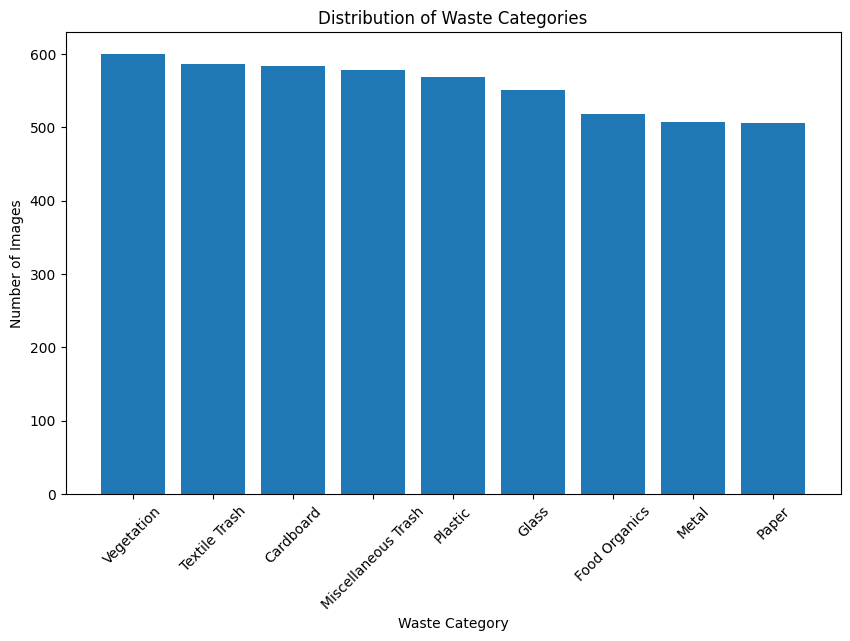

In [ ]:
# understand the distribution of  categories
category_counts = df_description['category'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index,category_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Waste Categories')
plt.show()

#WASTE POLICY DOCUMENTS DATASET

In [5]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
# df_policy_documents =  pd.read_json('waste_policy_documents.json')
# df_policy_documents
df_policy_documents = pd.read_json('/content/sample_data/waste_policy_documents.json')
df_policy_documents

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...,Metro City
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,METAL RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,PAPER RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,MISCELLANEOUS TRASH GUIDELINES\n\nItems That C...,Metro City
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,MUNICIPAL WASTE GUIDELINES\n\nGENERAL REQUIREM...,Metro City


In [ ]:
#Checking the shape of the dataset
print(df_policy_documents.shape)

(14, 6)


In [ ]:
#Understanding document organization an language

print(df_policy_documents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes
None


In [ ]:
#checking the column names
print(df_policy_documents.columns)

Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='object')


In [ ]:
#Checking the datatypes for each column
print(df_policy_documents.dtypes)

policy_id              int64
policy_type           object
categories_covered    object
effective_date        object
document_text         object
jurisdiction          object
dtype: object


In [ ]:
#Checking if there are duplicates
df_policy_documents.duplicated().sum()

TypeError: unhashable type: 'list'

### 1.3 Create Data Pipelines

In [ ]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

In [6]:
# Install package (first run only)
# !pip install -q sentence-transformers

# import pandas as pd
# import numpy as np
# import re
# import string

# from sklearn.model_selection import train_test_split
# from sentence_transformers import SentenceTransformer

# ==========================================================
# TEXT CLEANING FUNCTION
# ==========================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ==========================================================
# COMBINE USEFUL TEXT FIELDS
# ==========================================================

df_description["combined_text"] = (
    df_description["description"].fillna("") + " " +
    df_description["disposal_instruction"].fillna("") + " " +
    df_description["common_confusion"].fillna("") + " " +
    df_description["material_composition"].fillna("")
)

df_policy_documents["combined_text"] = (
    df_policy_documents["policy_type"].fillna("") + " " +
    df_policy_documents["categories_covered"].fillna("").astype(str) + " " +
    df_policy_documents["document_text"].fillna("") + " " +
    df_policy_documents["jurisdiction"].fillna("")
)

# ==========================================================
# CLEAN TEXT
# ==========================================================

df_description["clean_text"] = (
    df_description["combined_text"]
    .apply(clean_text)
)

df_policy_documents["clean_text"] = (
    df_policy_documents["combined_text"]
    .apply(clean_text)
)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

train_desc, test_desc = train_test_split(
    df_description,
    test_size=0.20,
    random_state=42,
    stratify=df_description["category"]
)

print(f"Training descriptions: {len(train_desc)}")
print(f"Testing descriptions : {len(test_desc)}")

# ==========================================================
# LOAD SENTENCE TRANSFORMER MODEL
# ==========================================================

model = SentenceTransformer('all-MiniLM-L6-v2')

# ==========================================================
# CREATE EMBEDDINGS
# ==========================================================

description_embeddings = model.encode(
    df_description["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

policy_embeddings = model.encode(
    df_policy_documents["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

# ==========================================================
# EMBEDDING DATAFRAMES
# ==========================================================

description_embedding_df = pd.DataFrame(description_embeddings)

description_embedding_df.insert(
    0,
    "category",
    df_description["category"]
)

policy_embedding_df = pd.DataFrame(policy_embeddings)

policy_embedding_df.insert(
    0,
    "policy_id",
    df_policy_documents["policy_id"]
)

# ==========================================================
# SAVE EMBEDDINGS
# ==========================================================

description_embedding_df.to_csv(
    "waste_description_embeddings.csv",
    index=False
)

policy_embedding_df.to_csv(
    "policy_document_embeddings.csv",
    index=False
)

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nDescription Embeddings Shape:")
print(description_embeddings.shape)

print("\nPolicy Embeddings Shape:")
print(policy_embeddings.shape)

print("\nEmbedding Dimensions:")
print(description_embeddings.shape[1])

print("\nDescription Categories:")
print(df_description["category"].value_counts())

print("\nSample Waste Record:")
print(df_description[["description","category"]].head(1))

print("\nSample Policy Record:")
print(df_policy_documents[["policy_id","policy_type"]].head(1))

print("\nFiles Saved:")
print("- waste_description_embeddings.csv")
print("- policy_document_embeddings.csv")

Training descriptions: 4000
Testing descriptions : 1000


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Description Embeddings Shape:
(5000, 384)

Policy Embeddings Shape:
(14, 384)

Embedding Dimensions:
384

Description Categories:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64

Sample Waste Record:
                description       category
0  soiled silver tablecloth  Textile Trash

Sample Policy Record:
   policy_id                         policy_type
0          1  Textile Trash Recycling Guidelines

Files Saved:
- waste_description_embeddings.csv
- policy_document_embeddings.csv


In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

In [ ]:
# Unzip the RealWaste dataset into a directory named 'RealWaste'
!unzip -q '/content/sample_data/realwaste.zip' -d 'RealWaste'

In [ ]:
import tensorflow as tf

# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 1
Class names: ['realwaste-main']
Total images found: 0
Found 4752 files belonging to 1 classes.
Using 3802 files for training.
Found 4752 files belonging to 1 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


WASTE DESCRIPTION TEXT CLASSIFICATION
Device being used: cuda
GPU: Tesla T4

Loading dataset from: /content/sample_data/waste_descriptions.csv
Original dataset shape: (5000, 5)
Columns found: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Detected columns
Description column: description
Category column:    category

Cleaned dataset shape: (4939, 2)
Number of categories: 9

Category distribution:


,record_count
label,
Vegetation,589
Textile Trash,585
Cardboard,581
Miscellaneous Trash,577
Plastic,555
Glass,541
Food Organics,511
Metal,504
Paper,496



Label mapping:
  0: Cardboard
  1: Food Organics
  2: Glass
  3: Metal
  4: Miscellaneous Trash
  5: Paper
  6: Plastic
  7: Textile Trash
  8: Vegetation

Dataset split:
Training records:   3,457
Validation records: 741
Test records:       741
Total records:      4,939

Training category distribution:


...


Epoch 2/3
  Training loss:       0.0568
  Validation loss:     0.0140
  Training accuracy:   0.9980
  Validation accuracy: 1.0000
  Best model updated.


Epoch 3/3:   0%|          | 0/217 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]


Epoch 3/3
  Training loss:       0.0172
  Validation loss:     0.0096
  Training accuracy:   0.9997
  Validation accuracy: 1.0000

Training history:


,epoch,training_loss,validation_loss,training_accuracy,validation_accuracy
0,1,1.2481,0.1484,0.6572,0.9933
1,2,0.0568,0.0140,0.9980,1.0000
2,3,0.0172,0.0096,0.9997,1.0000


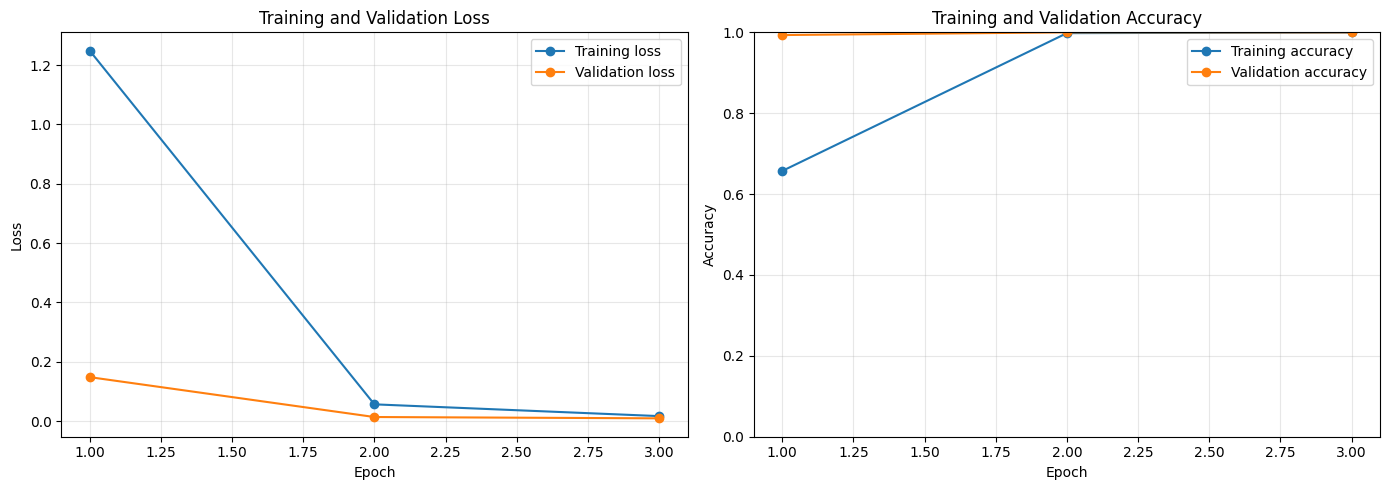


TEST SET EVALUATION


Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

Test loss:     0.0194
Test accuracy: 0.9987
Test accuracy: 99.87%

Classification report:


,precision,recall,f1-score,support
Cardboard,1.0000,1.0000,1.0000,87.0000
Food Organics,1.0000,1.0000,1.0000,76.0000
Glass,0.9878,1.0000,0.9939,81.0000
Metal,1.0000,1.0000,1.0000,75.0000
Miscellaneous Trash,1.0000,0.9885,0.9942,87.0000
Paper,1.0000,1.0000,1.0000,75.0000
Plastic,1.0000,1.0000,1.0000,84.0000
Textile Trash,1.0000,1.0000,1.0000,88.0000
Vegetation,1.0000,1.0000,1.0000,88.0000
accuracy,0.9987,0.9987,0.9987,0.9987


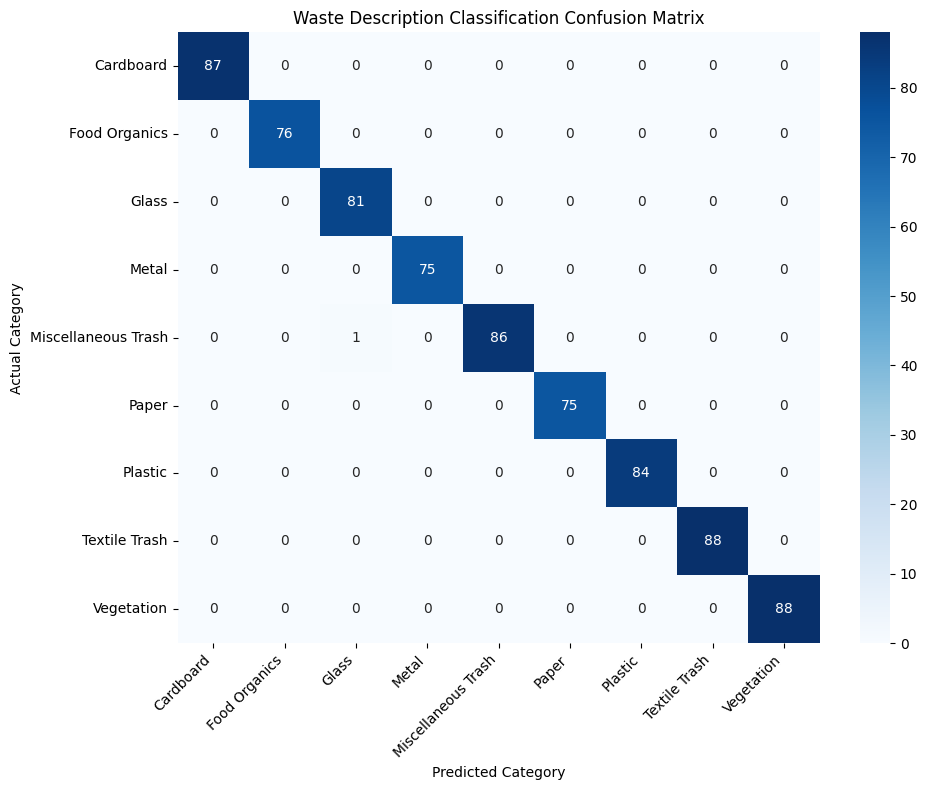


ERROR ANALYSIS
Correct test predictions: 740
Incorrect test predictions: 1

Misclassified descriptions, starting with the highest-confidence errors:


,text,actual_category,predicted_category,confidence
0,striped glass toy with food residue,Miscellaneous Trash,Glass,93.51%



Most common category confusion patterns:


,actual_category,predicted_category,error_count
0,Miscellaneous Trash,Glass,1



Description-length and confidence comparison:


,group,average_words,median_words,average_confidence
0,Correct predictions,4.845,5.0,0.986
1,Incorrect predictions,6.000,6.0,0.935



Detailed classification errors saved to: /content/waste_classification_errors.csv

Most challenging descriptions based on low confidence:


,text,actual_category,predicted_category,confidence,correct_prediction
191,crumpled enormous yellow metal CD/DVD partially filled,Miscellaneous Trash,Miscellaneous Trash,89.60%,True
540,striped glass toy with food residue,Miscellaneous Trash,Glass,93.51%,False
199,full massive floral toy with product remaining,Miscellaneous Trash,Miscellaneous Trash,94.23%,True
180,intact purple Designer soda bottle with product remaining,Plastic,Plastic,95.72%,True
417,dry bottle cap,Metal,Metal,96.92%,True
646,wrinkled tiny green bottle cap partially filled,Metal,Metal,96.94%,True
229,wrinkled standard blue Eco-Friendly vegetable waste with label attached,Food Organics,Food Organics,96.94%,True
70,large bottle cap,Metal,Metal,97.14%,True
92,black Artisanal bottle cap empty,Metal,Metal,97.14%,True
502,new newspaper,Paper,Paper,97.55%,True


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer saved to: /content/waste_distilbert_model

EXAMPLE PREDICTIONS

Description: An empty plastic water bottle
Predicted category: Plastic
Confidence: 98.37%

Description: Used cardboard packaging box
Predicted category: Cardboard
Confidence: 98.82%

Description: Broken glass drinking bottle
Predicted category: Glass
Confidence: 98.60%

Description: Leftover food and vegetable peels
Predicted category: Food Organics
Confidence: 98.25%

TRAINING AND EVALUATION COMPLETED

Use the trained model as follows:
predict_waste_category('your waste description here')

To see category probabilities, use:
predict_waste_category('your waste description here', return_all_probabilities=True)


In [ ]:
# ============================================================
# DISTILBERT WASTE DESCRIPTION CLASSIFIER
# Complete Colab workflow in one cell
# ============================================================

# ------------------------------------------------------------
# 1. Install required packages
# ------------------------------------------------------------
!pip -q install -U transformers datasets accelerate scikit-learn seaborn

# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 3. Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 4. Configuration
# ------------------------------------------------------------
CSV_PATH = "/content/sample_data/waste_descriptions.csv"

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

MODEL_OUTPUT_PATH = "/content/waste_distilbert_model"
ERROR_OUTPUT_PATH = "/content/waste_classification_errors.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("WASTE DESCRIPTION TEXT CLASSIFICATION")
print("=" * 70)
print(f"Device being used: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print(
        "WARNING: GPU is not enabled. "
        "In Colab select Runtime > Change runtime type > T4 GPU."
    )

# ------------------------------------------------------------
# 5. Locate the CSV file if the configured path is incorrect
# ------------------------------------------------------------
csv_path = Path(CSV_PATH)

if not csv_path.exists():
    matching_files = list(Path("/content").rglob("waste_descriptions.csv"))

    if matching_files:
        csv_path = matching_files[0]
        print(f"\nCSV found automatically at: {csv_path}")
    else:
        csv_files = list(Path("/content").rglob("*.csv"))

        print("\nCSV files found under /content:")
        for file in csv_files:
            print(f"  {file}")

        raise FileNotFoundError(
            "The file waste_descriptions.csv was not found under /content. "
            "Confirm that it is uploaded and check its exact filename."
        )

print(f"\nLoading dataset from: {csv_path}")

# ------------------------------------------------------------
# 6. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(csv_path)

print(f"Original dataset shape: {df.shape}")
print(f"Columns found: {df.columns.tolist()}")

display(df.head())

# ------------------------------------------------------------
# 7. Automatically identify text and category columns
# ------------------------------------------------------------
def normalise_column_name(column):
    return re.sub(r"[^a-z0-9]+", "_", str(column).strip().lower()).strip("_")


normalised_columns = {
    normalise_column_name(column): column
    for column in df.columns
}

text_candidates = [
    "description",
    "waste_description",
    "text",
    "waste_text",
    "item_description",
    "material_description",
    "product_description",
    "details",
    "sentence",
    "input"
]

label_candidates = [
    "category",
    "waste_category",
    "label",
    "class",
    "waste_type",
    "material_category",
    "target",
    "output"
]

TEXT_COLUMN = next(
    (
        normalised_columns[column]
        for column in text_candidates
        if column in normalised_columns
    ),
    None
)

LABEL_COLUMN = next(
    (
        normalised_columns[column]
        for column in label_candidates
        if column in normalised_columns
    ),
    None
)

# If common names are not found, infer columns from their contents.
if TEXT_COLUMN is None:
    object_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()

    if object_columns:
        average_lengths = {
            column: df[column].dropna().astype(str).str.len().mean()
            for column in object_columns
        }

        TEXT_COLUMN = max(
            average_lengths,
            key=average_lengths.get
        )

if LABEL_COLUMN is None:
    possible_label_columns = [
        column
        for column in df.columns
        if column != TEXT_COLUMN
        and 1 < df[column].nunique(dropna=True) <= min(100, len(df))
    ]

    if possible_label_columns:
        LABEL_COLUMN = min(
            possible_label_columns,
            key=lambda column: df[column].nunique(dropna=True)
        )

if TEXT_COLUMN is None or LABEL_COLUMN is None:
    raise ValueError(
        "\nThe code could not automatically identify the description and "
        "category columns.\n"
        f"Columns available: {df.columns.tolist()}\n\n"
        "Set the columns manually near the start of the code, for example:\n"
        "TEXT_COLUMN = 'description'\n"
        "LABEL_COLUMN = 'category'"
    )

if TEXT_COLUMN == LABEL_COLUMN:
    raise ValueError(
        "The detected text and label columns are the same. "
        "Set TEXT_COLUMN and LABEL_COLUMN manually."
    )

print("\nDetected columns")
print(f"Description column: {TEXT_COLUMN}")
print(f"Category column:    {LABEL_COLUMN}")

# ------------------------------------------------------------
# 8. Clean the dataset
# ------------------------------------------------------------
data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()

data.columns = ["text", "label"]

data = data.dropna(subset=["text", "label"])

data["text"] = (
    data["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

data["label"] = (
    data["label"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove empty records.
data = data[
    (data["text"].str.len() > 0) &
    (data["label"].str.len() > 0)
].copy()

# Remove exact duplicate description-category pairs.
data = data.drop_duplicates(
    subset=["text", "label"]
).reset_index(drop=True)

if len(data) == 0:
    raise ValueError("No usable records remain after cleaning the dataset.")

print(f"\nCleaned dataset shape: {data.shape}")
print(f"Number of categories: {data['label'].nunique()}")

print("\nCategory distribution:")
category_counts = data["label"].value_counts()
display(category_counts.rename("record_count").to_frame())

# Warn about very small classes.
small_classes = category_counts[category_counts < 5]

if len(small_classes) > 0:
    print(
        "\nWARNING: The following categories have fewer than five records. "
        "Reliable stratified splitting and evaluation may be difficult:"
    )
    display(small_classes.rename("record_count").to_frame())

# ------------------------------------------------------------
# 9. Encode category labels
# ------------------------------------------------------------
class_names = sorted(data["label"].unique().tolist())

label_to_id = {
    label: index
    for index, label in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

data["label_id"] = data["label"].map(label_to_id)

NUM_LABELS = len(class_names)

print("\nLabel mapping:")
for label, label_id in label_to_id.items():
    print(f"  {label_id}: {label}")

if NUM_LABELS < 2:
    raise ValueError(
        "Text classification requires at least two waste categories."
    )

# ------------------------------------------------------------
# 10. Split into training, validation and test sets
#     Target split: 70% training, 15% validation, 15% test
# ------------------------------------------------------------
minimum_class_count = data["label"].value_counts().min()

use_stratification = minimum_class_count >= 3

if use_stratification:
    stratify_all = data["label_id"]
else:
    stratify_all = None
    print(
        "\nWARNING: Stratification has been disabled because at least one "
        "category has fewer than three records."
    )

train_df, temporary_df = train_test_split(
    data,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_all
)

temporary_minimum = temporary_df["label"].value_counts().min()

if use_stratification and temporary_minimum >= 2:
    temporary_stratify = temporary_df["label_id"]
else:
    temporary_stratify = None

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_stratify
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nDataset split:")
print(f"Training records:   {len(train_df):,}")
print(f"Validation records: {len(validation_df):,}")
print(f"Test records:       {len(test_df):,}")
print(f"Total records:      {len(data):,}")

print("\nTraining category distribution:")
display(
    train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
    .rename("training_records")
    .to_frame()
)

# ------------------------------------------------------------
# 11. Load DistilBERT tokenizer
# ------------------------------------------------------------
print(f"\nLoading tokenizer: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ------------------------------------------------------------
# 12. Create a PyTorch Dataset
# ------------------------------------------------------------
class WasteTextDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length
    ):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = int(self.labels[index])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            key: value.squeeze(0)
            for key, value in encoding.items()
        }

        item["labels"] = torch.tensor(
            label,
            dtype=torch.long
        )

        return item


train_dataset = WasteTextDataset(
    train_df,
    tokenizer,
    MAX_LENGTH
)

validation_dataset = WasteTextDataset(
    validation_df,
    tokenizer,
    MAX_LENGTH
)

test_dataset = WasteTextDataset(
    test_df,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# 13. Load DistilBERT classification model
# ------------------------------------------------------------
print(f"\nLoading model: {MODEL_NAME}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)

model = model.to(DEVICE)

# Explicitly ensure that all layers are trainable.
for parameter in model.parameters():
    parameter.requires_grad = True

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total model parameters:     {total_parameters:,}")
print(f"Trainable parameters:       {trainable_parameters:,}")
print(
    "All pretrained layers trainable: "
    f"{total_parameters == trainable_parameters}"
)

# ------------------------------------------------------------
# 14. Optimiser and learning-rate scheduler
# ------------------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * total_training_steps),
    num_training_steps=total_training_steps
)

# ------------------------------------------------------------
# 15. Evaluation function
# ------------------------------------------------------------
def evaluate_model(
    model,
    data_loader,
    device
):
    model.eval()

    total_loss = 0.0
    predictions = []
    actual_labels = []
    probabilities = []

    with torch.no_grad():
        for batch in tqdm(
            data_loader,
            desc="Evaluating",
            leave=False
        ):
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(**batch)

            loss = outputs.loss
            logits = outputs.logits

            batch_probabilities = torch.softmax(
                logits,
                dim=1
            )

            batch_predictions = torch.argmax(
                batch_probabilities,
                dim=1
            )

            total_loss += loss.item()

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

            actual_labels.extend(
                batch["labels"].cpu().numpy()
            )

            probabilities.extend(
                batch_probabilities.cpu().numpy()
            )

    average_loss = total_loss / max(len(data_loader), 1)

    accuracy = accuracy_score(
        actual_labels,
        predictions
    )

    return (
        average_loss,
        accuracy,
        np.array(predictions),
        np.array(actual_labels),
        np.array(probabilities)
    )

# ------------------------------------------------------------
# 16. Train all DistilBERT layers
# ------------------------------------------------------------
best_validation_accuracy = -1.0
best_model_state = None
training_history = []

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    training_predictions = []
    training_labels = []

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for batch in progress_bar:

        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        # Prevent extreme gradient values.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        batch_predictions = torch.argmax(
            logits,
            dim=1
        )

        training_predictions.extend(
            batch_predictions.detach().cpu().numpy()
        )

        training_labels.extend(
            batch["labels"].detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    training_loss = running_loss / max(len(train_loader), 1)

    training_accuracy = accuracy_score(
        training_labels,
        training_predictions
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _,
        _
    ) = evaluate_model(
        model,
        validation_loader,
        DEVICE
    )

    training_history.append({
        "epoch": epoch + 1,
        "training_loss": training_loss,
        "validation_loss": validation_loss,
        "training_accuracy": training_accuracy,
        "validation_accuracy": validation_accuracy
    })

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
        f"\n  Training loss:       {training_loss:.4f}"
        f"\n  Validation loss:     {validation_loss:.4f}"
        f"\n  Training accuracy:   {training_accuracy:.4f}"
        f"\n  Validation accuracy: {validation_accuracy:.4f}"
    )

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        print("  Best model updated.")

# Restore the best validation model.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(DEVICE)

# ------------------------------------------------------------
# 17. Display training history
# ------------------------------------------------------------
history_df = pd.DataFrame(training_history)

print("\nTraining history:")
display(history_df.round(4))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    history_df["epoch"],
    history_df["training_loss"],
    marker="o",
    label="Training loss"
)

axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation loss"
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["training_accuracy"],
    marker="o",
    label="Training accuracy"
)

axes[1].plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 18. Final test-set evaluation
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

(
    test_loss,
    test_accuracy,
    test_predictions,
    test_actual_labels,
    test_probabilities
) = evaluate_model(
    model,
    test_loader,
    DEVICE
)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# ------------------------------------------------------------
# 19. Classification report
# ------------------------------------------------------------
all_label_ids = list(range(NUM_LABELS))

report = classification_report(
    test_actual_labels,
    test_predictions,
    labels=all_label_ids,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\nClassification report:")
display(report_df.round(4))

# ------------------------------------------------------------
# 20. Confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    test_actual_labels,
    test_predictions,
    labels=all_label_ids
)

figure_width = max(10, NUM_LABELS * 0.9)
figure_height = max(8, NUM_LABELS * 0.75)

plt.figure(
    figsize=(figure_width, figure_height)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Waste Description Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 21. Create detailed test results
# ------------------------------------------------------------
result_df = test_df[
    ["text", "label", "label_id"]
].copy()

result_df["predicted_label_id"] = test_predictions

result_df["predicted_category"] = [
    id_to_label[int(prediction)]
    for prediction in test_predictions
]

result_df["confidence"] = test_probabilities.max(axis=1)

result_df["correct_prediction"] = (
    result_df["label_id"] ==
    result_df["predicted_label_id"]
)

result_df = result_df.rename(
    columns={
        "label": "actual_category"
    }
)

# Add probability for every category.
for category_index, category_name in id_to_label.items():
    safe_category_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        category_name
    ).strip("_")

    result_df[
        f"probability_{safe_category_name}"
    ] = test_probabilities[:, category_index]

# ------------------------------------------------------------
# 22. Analyse error patterns
# ------------------------------------------------------------
errors_df = result_df[
    result_df["correct_prediction"] == False
].copy()

errors_df = errors_df.sort_values(
    by="confidence",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print(f"Correct test predictions: {result_df['correct_prediction'].sum()}")
print(f"Incorrect test predictions: {len(errors_df)}")

if len(errors_df) > 0:

    print(
        "\nMisclassified descriptions, starting with the "
        "highest-confidence errors:"
    )

    display(
        errors_df[
            [
                "text",
                "actual_category",
                "predicted_category",
                "confidence"
            ]
        ].head(30).style.format({
            "confidence": "{:.2%}"
        })
    )

    confusion_patterns = (
        errors_df
        .groupby(
            ["actual_category", "predicted_category"]
        )
        .size()
        .reset_index(name="error_count")
        .sort_values(
            "error_count",
            ascending=False
        )
    )

    print("\nMost common category confusion patterns:")
    display(confusion_patterns.head(20))

    # Description length analysis.
    errors_df["description_word_count"] = (
        errors_df["text"]
        .str.split()
        .str.len()
    )

    correct_df = result_df[
        result_df["correct_prediction"] == True
    ].copy()

    correct_df["description_word_count"] = (
        correct_df["text"]
        .str.split()
        .str.len()
    )

    error_length_summary = pd.DataFrame({
        "group": [
            "Correct predictions",
            "Incorrect predictions"
        ],
        "average_words": [
            correct_df["description_word_count"].mean(),
            errors_df["description_word_count"].mean()
        ],
        "median_words": [
            correct_df["description_word_count"].median(),
            errors_df["description_word_count"].median()
        ],
        "average_confidence": [
            correct_df["confidence"].mean(),
            errors_df["confidence"].mean()
        ]
    })

    print("\nDescription-length and confidence comparison:")
    display(error_length_summary.round(3))

    errors_df.to_csv(
        ERROR_OUTPUT_PATH,
        index=False
    )

    print(
        f"\nDetailed classification errors saved to: "
        f"{ERROR_OUTPUT_PATH}"
    )

else:
    print(
        "\nNo misclassifications were found in the test set."
    )

# ------------------------------------------------------------
# 23. Identify challenging low-confidence descriptions
# ------------------------------------------------------------
challenging_df = (
    result_df
    .sort_values(
        "confidence",
        ascending=True
    )
    [
        [
            "text",
            "actual_category",
            "predicted_category",
            "confidence",
            "correct_prediction"
        ]
    ]
    .head(20)
)

print("\nMost challenging descriptions based on low confidence:")
display(
    challenging_df.style.format({
        "confidence": "{:.2%}"
    })
)

# ------------------------------------------------------------
# 24. Save model, tokenizer and label mapping
# ------------------------------------------------------------
os.makedirs(
    MODEL_OUTPUT_PATH,
    exist_ok=True
)

model.save_pretrained(MODEL_OUTPUT_PATH)
tokenizer.save_pretrained(MODEL_OUTPUT_PATH)

with open(
    os.path.join(
        MODEL_OUTPUT_PATH,
        "label_mapping.json"
    ),
    "w",
    encoding="utf-8"
) as mapping_file:
    json.dump(
        {
            "label_to_id": label_to_id,
            "id_to_label": {
                str(key): value
                for key, value in id_to_label.items()
            }
        },
        mapping_file,
        indent=4,
        ensure_ascii=False
    )

print(
    f"\nModel and tokenizer saved to: "
    f"{MODEL_OUTPUT_PATH}"
)

# ------------------------------------------------------------
# 25. Prediction function
# ------------------------------------------------------------
def predict_waste_category(
    description,
    return_all_probabilities=False
):
    """
    Predict the waste category for a text description.

    Parameters
    ----------
    description : str
        Waste description to classify.

    return_all_probabilities : bool
        If True, returns probabilities for every category.

    Returns
    -------
    dict
        Predicted category, confidence and optional probabilities.
    """

    if description is None:
        raise ValueError(
            "The waste description cannot be None."
        )

    clean_description = re.sub(
        r"\s+",
        " ",
        str(description)
    ).strip()

    if not clean_description:
        raise ValueError(
            "Please provide a non-empty waste description."
        )

    model.eval()

    encoded_input = tokenizer(
        clean_description,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    encoded_input = {
        key: value.to(DEVICE)
        for key, value in encoded_input.items()
    }

    with torch.no_grad():
        outputs = model(**encoded_input)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )[0].cpu().numpy()

    predicted_id = int(np.argmax(probabilities))
    predicted_category = id_to_label[predicted_id]
    confidence = float(probabilities[predicted_id])

    prediction_result = {
        "description": clean_description,
        "predicted_category": predicted_category,
        "confidence": confidence
    }

    if return_all_probabilities:
        prediction_result["all_probabilities"] = {
            id_to_labelfloat(probability)
            for index, probability in enumerate(probabilities)
        }

    return prediction_result


# ------------------------------------------------------------
# 26. Test the prediction function
# ------------------------------------------------------------
example_descriptions = [
    "An empty plastic water bottle",
    "Used cardboard packaging box",
    "Broken glass drinking bottle",
    "Leftover food and vegetable peels"
]

print("\n" + "=" * 70)
print("EXAMPLE PREDICTIONS")
print("=" * 70)

for description in example_descriptions:
    prediction = predict_waste_category(description)

    print(f"\nDescription: {prediction['description']}")
    print(
        f"Predicted category: "
        f"{prediction['predicted_category']}"
    )
    print(
        f"Confidence: "
        f"{prediction['confidence']:.2%}"
    )

print("\n" + "=" * 70)
print("TRAINING AND EVALUATION COMPLETED")
print("=" * 70)

print(
    "\nUse the trained model as follows:\n"
    "predict_waste_category('your waste description here')"
)

print(
    "\nTo see category probabilities, use:\n"
    "predict_waste_category("
    "'your waste description here', "
    "return_all_probabilities=True)"
)

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

REALWASTE IMAGE CLASSIFICATION PIPELINE

ZIP path: /content/sample_data/realwaste.zip
ZIP size: 656.65 MB
ZIP validation: PASSED

Extraction directory already exists: /content/RealWaste
Existing extracted data will be used.

Detected dataset directory: /content/RealWaste/realwaste-main/RealWaste
Detected class folders: 9
Detected images: 4752

Class names:
 0. Cardboard: 461 images
 1. Food Organics: 411 images
 2. Glass: 420 images
 3. Metal: 790 images
 4. Miscellaneous Trash: 495 images
 5. Paper: 500 images
 6. Plastic: 921 images
 7. Textile Trash: 318 images
 8. Vegetation: 436 images

Total usable image files: 4,752

Dataset split:
Training:   3,326 images (70.0%)
Validation: 713 images (15.0%)
Test:       713 images (15.0%)

Preprocessing verification:
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Normalised pixel range: -1.0000 to 1.0000
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model architecture:


Model: "RealWaste_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_batch_normalisation      │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer (Dense)      │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ waste_category_output (Dense)   │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,353 (9.89 MB)

 Trainable params: 332,809 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


STAGE 1: TRAINING CUSTOM CLASSIFICATION LAYERS
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4386 - loss: 1.8318
Epoch 1: val_accuracy improved from None to 0.62833, saving model to /content/best_realwaste_model.keras

Epoch 1: finished saving model to /content/best_realwaste_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.5424 - loss: 1.5035 - val_accuracy: 0.6283 - val_loss: 1.0194 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7054 - loss: 0.9189
Epoch 2: val_accuracy did not improve from 0.62833
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.7084 - loss: 0.9012 - val_accuracy: 0.6283 - val_loss: 1.1037 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7624 - loss: 0.7196
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy improved from 0.62833 to 0.63534, saving model to /content/best_realwaste_mo

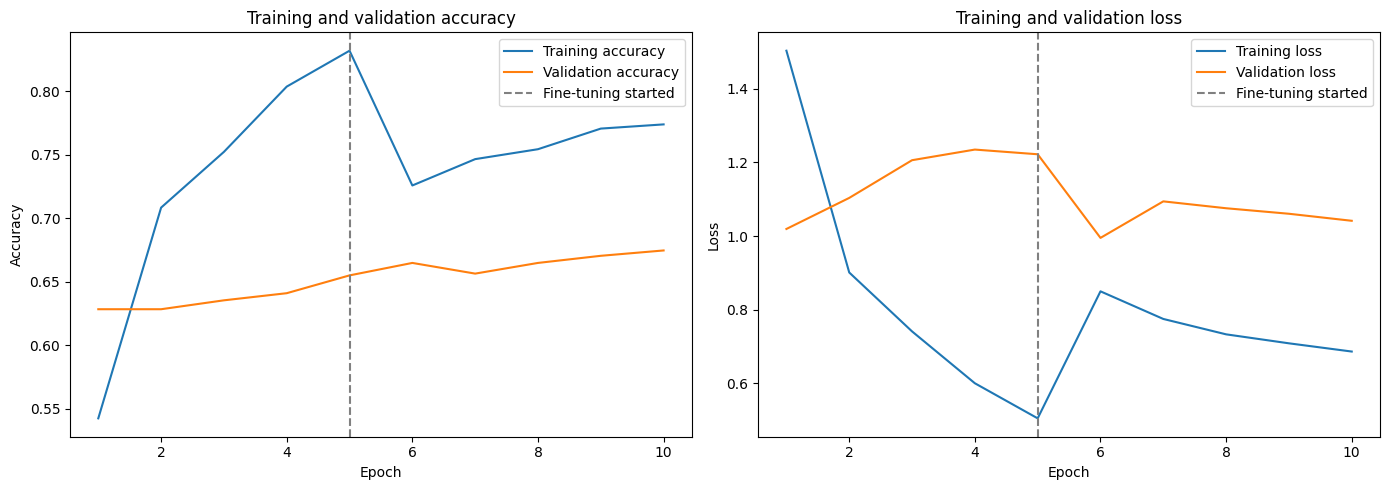


TEST-SET EVALUATION
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6830 - loss: 1.0973

Test loss:     1.0973
Test accuracy: 68.3029%
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step
Confirmed test accuracy: 68.3029%

Classification report:


,precision,recall,f1-score,support
Cardboard,0.7742,0.6957,0.7328,69.000
Food Organics,1.0000,0.2419,0.3896,62.000
Glass,0.7273,0.6349,0.6780,63.000
Metal,0.7556,0.5763,0.6538,118.000
Miscellaneous Trash,0.4135,0.5733,0.4804,75.000
Paper,0.7671,0.7467,0.7568,75.000
Plastic,0.6319,0.8333,0.7188,138.000
Textile Trash,0.6615,0.8958,0.7611,48.000
Vegetation,0.8806,0.9077,0.8939,65.000
accuracy,0.6830,0.6830,0.6830,0.683


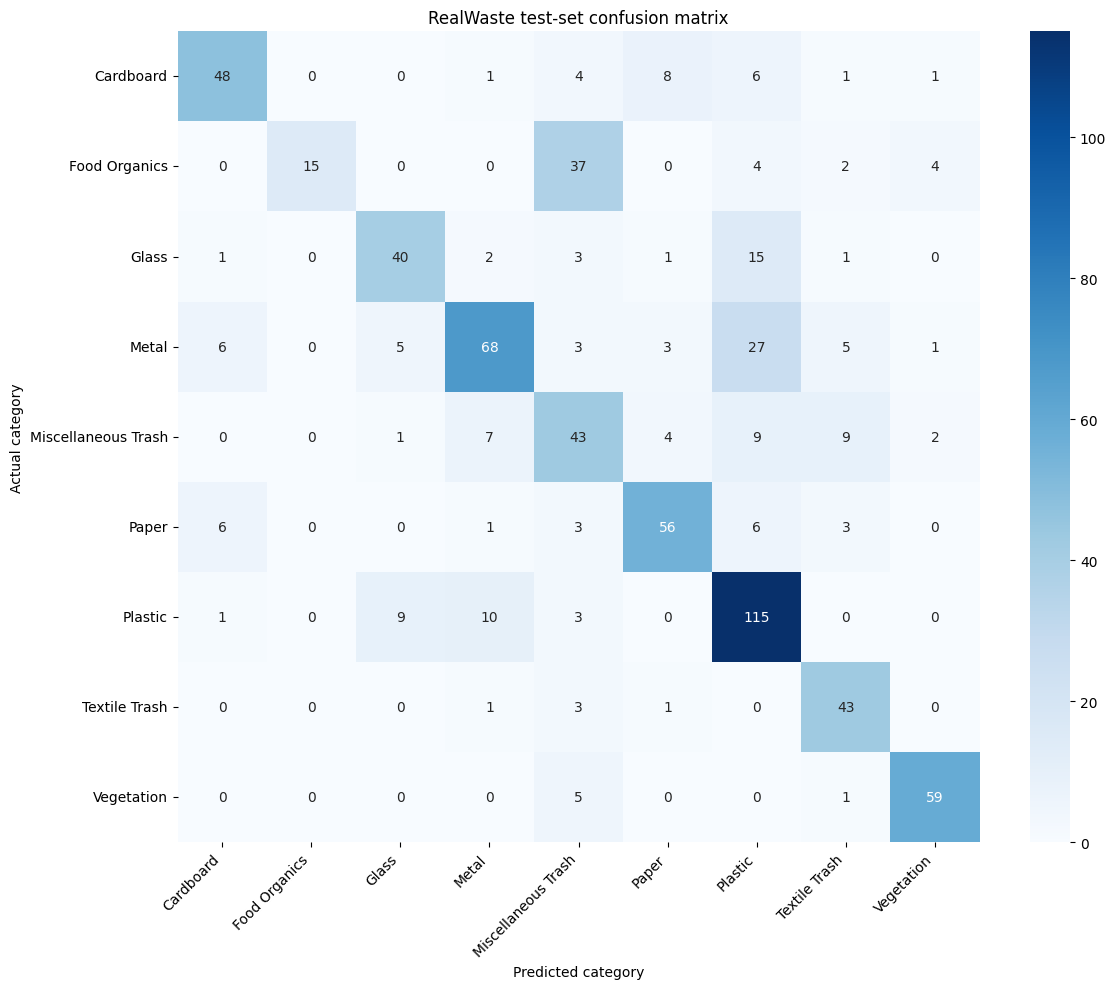

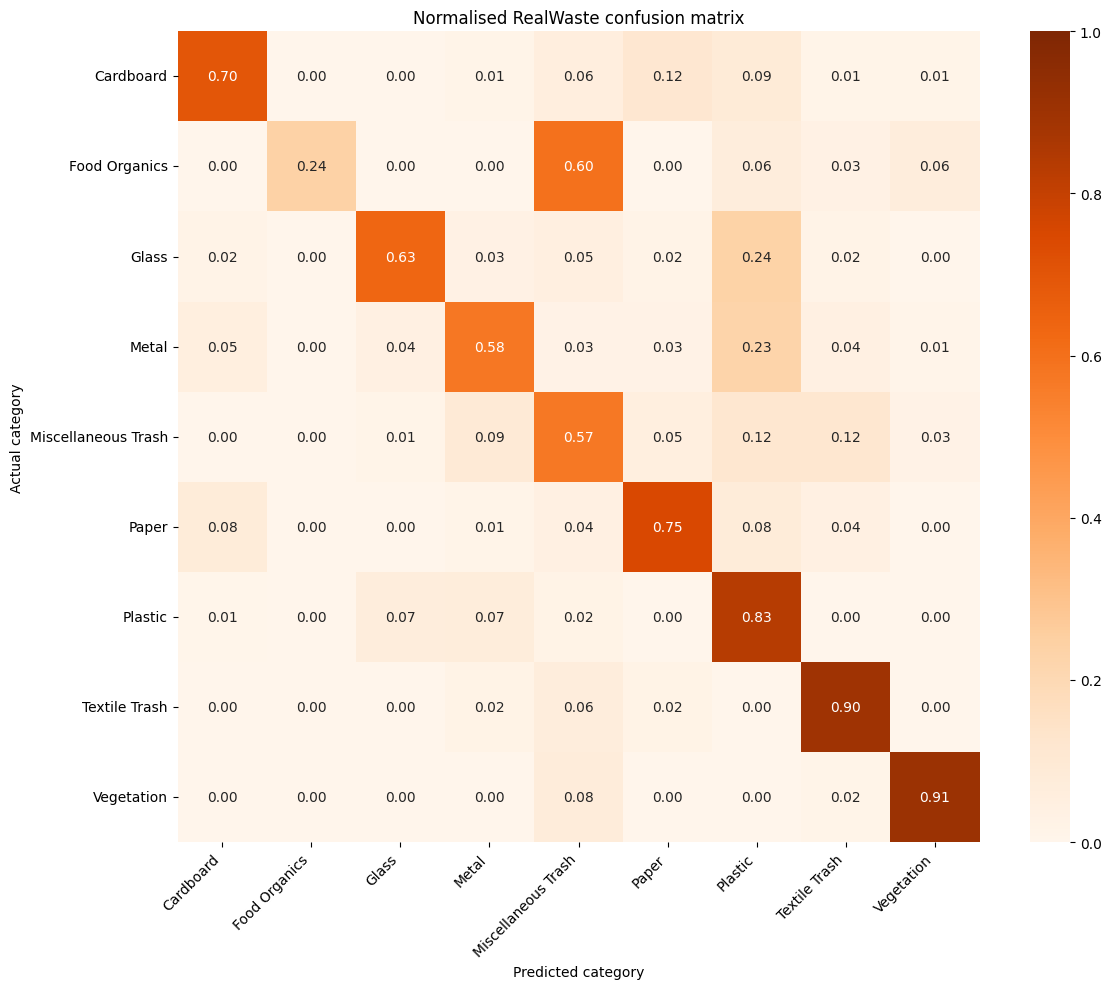


Category-level error analysis:


,category,test_images,correct,incorrect,category_accuracy,most_confused_with,confusion_count
0,Food Organics,62,15,47,24.19%,Miscellaneous Trash,37
1,Miscellaneous Trash,75,43,32,57.33%,Plastic,9
2,Metal,118,68,50,57.63%,Plastic,27
3,Glass,63,40,23,63.49%,Plastic,15
4,Cardboard,69,48,21,69.57%,Paper,8
5,Paper,75,56,19,74.67%,Cardboard,6
6,Plastic,138,115,23,83.33%,Metal,10
7,Textile Trash,48,43,5,89.58%,Miscellaneous Trash,3
8,Vegetation,65,59,6,90.77%,Miscellaneous Trash,5



Most frequent misclassification patterns:


,actual_category,predicted_category,error_count
0,Food Organics,Miscellaneous Trash,37
1,Metal,Plastic,27
2,Glass,Plastic,15
3,Plastic,Metal,10
4,Miscellaneous Trash,Plastic,9
5,Plastic,Glass,9
6,Miscellaneous Trash,Textile Trash,9
7,Cardboard,Paper,8
8,Miscellaneous Trash,Metal,7
9,Metal,Cardboard,6


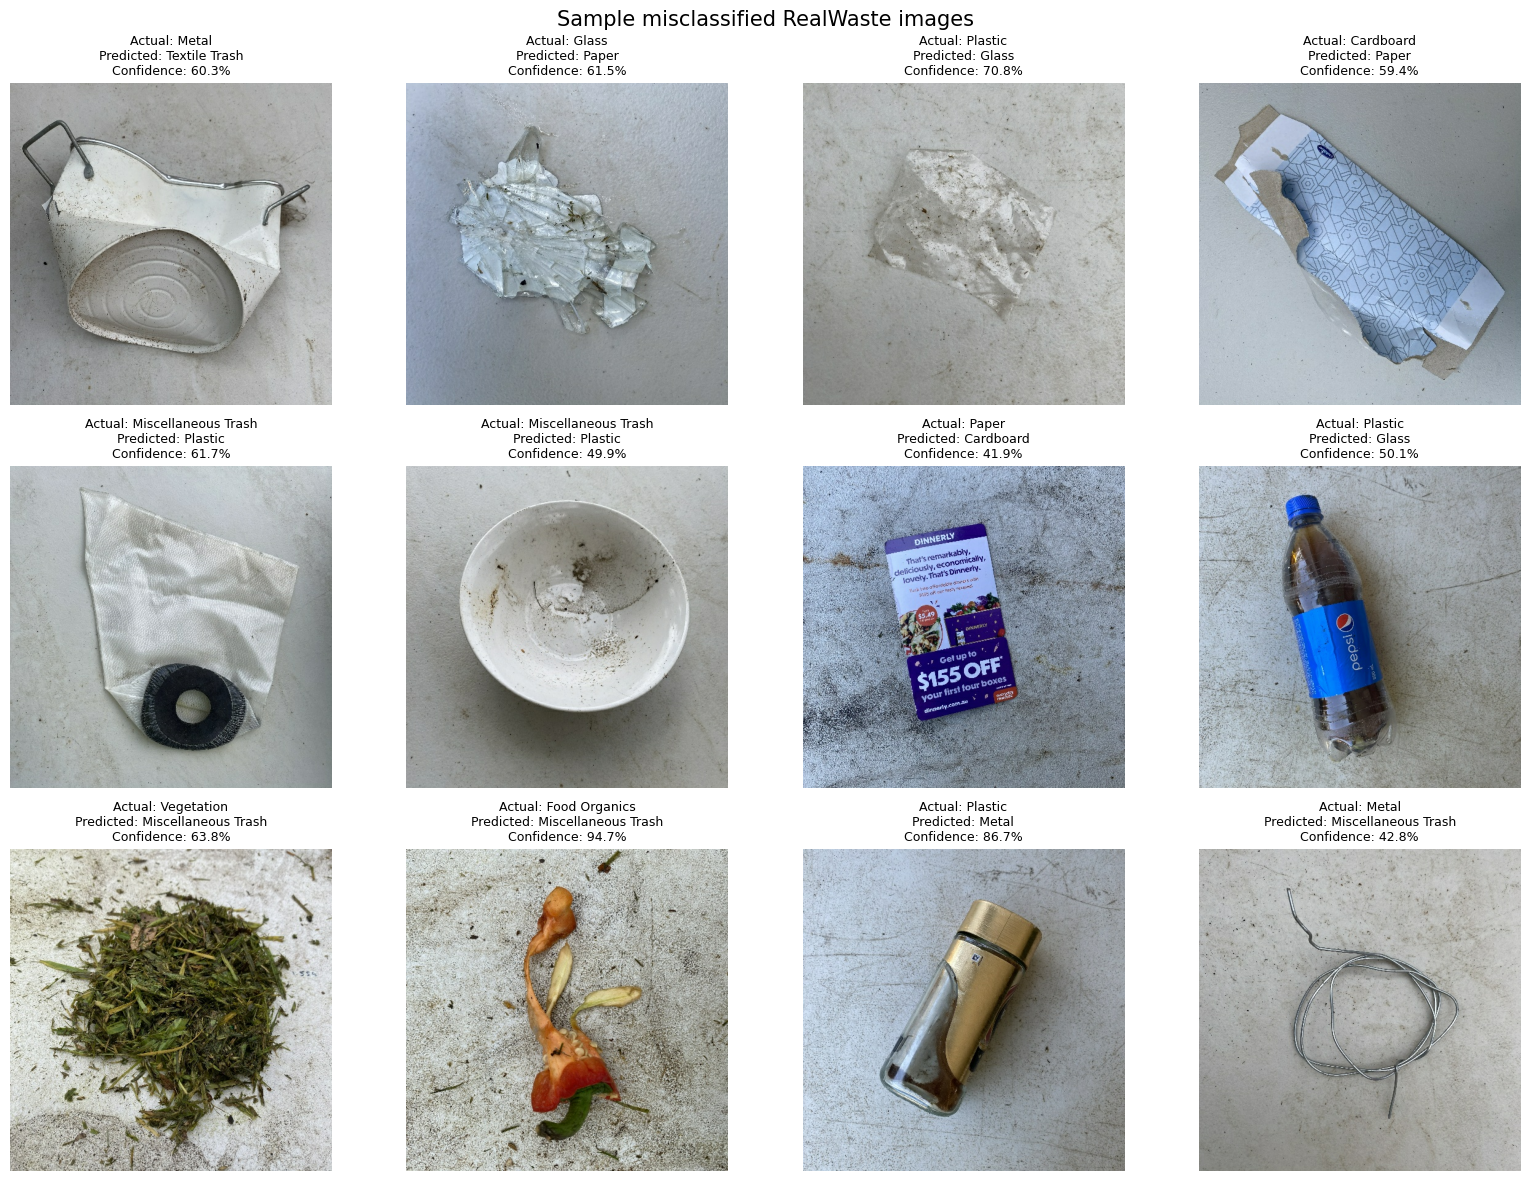


PIPELINE COMPLETED SUCCESSFULLY
Dataset directory: /content/RealWaste/realwaste-main/RealWaste
Number of classes: 9
Training images: 3,326
Validation images: 713
Test images: 713
Final test accuracy: 68.3029%
Final test loss: 1.0973

Tuning parameters used:
Custom dense-layer width: 256
Dropout rate: 0.4
L2 regularisation: 0.0001
Fine-tuned MobileNetV2 layers: 30
Initial learning rate: 0.001
Fine-tuning learning rate: 1e-05

Saved outputs:
 - Model: /content/realwaste_mobilenetv2_final.keras
 - Error analysis: /content/realwaste_category_error_analysis.csv
 - Classification report: /content/realwaste_classification_report.csv
 - Confusion matrix: /content/realwaste_confusion_matrix.csv
 - Confusion patterns: /content/realwaste_confusion_patterns.csv


In [ ]:
# ============================================================
# REALWASTE IMAGE CLASSIFICATION: COMPLETE ONE-CELL PIPELINE
# ============================================================

import os
import zipfile
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

warnings.filterwarnings("ignore")

# ============================================================
# 1. REPRODUCIBILITY AND PARAMETERS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ZIP_PATH = Path("/content/sample_data/realwaste.zip")
EXTRACT_DIR = Path("/content/RealWaste")

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10

INITIAL_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5

DENSE_UNITS = 256
DROPOUT_RATE = 0.40
L2_RATE = 1e-4

EXPECTED_CLASSES = 9

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".gif", ".webp"
}

print("=" * 70)
print("REALWASTE IMAGE CLASSIFICATION PIPELINE")
print("=" * 70)

# ============================================================
# 2. VALIDATE ZIP FILE
# ============================================================

if not ZIP_PATH.exists():
    available_zips = list(Path("/content").rglob("*.zip"))

    if available_zips:
        print("\nSpecified ZIP was not found.")
        print("ZIP files detected:")

        for detected_zip in available_zips:
            print(f" - {detected_zip}")

        likely_matches = [
            path for path in available_zips
            if "realwaste" in path.name.lower()
        ]

        if likely_matches:
            ZIP_PATH = likely_matches[0]
            print(f"\nAutomatically selected: {ZIP_PATH}")
        else:
            raise FileNotFoundError(
                "The RealWaste ZIP file was not found. "
                "Upload realwaste.zip to /content/sample_data/ "
                "or update ZIP_PATH."
            )
    else:
        raise FileNotFoundError(
            "No ZIP file was found under /content."
        )

file_size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

print(f"\nZIP path: {ZIP_PATH}")
print(f"ZIP size: {file_size_mb:.2f} MB")

if file_size_mb == 0:
    raise ValueError(
        "The uploaded ZIP file is empty. Upload the dataset again."
    )

if not zipfile.is_zipfile(ZIP_PATH):
    with open(ZIP_PATH, "rb") as file:
        signature = file.read(20)

    raise zipfile.BadZipFile(
        f"{ZIP_PATH.name} is not a valid ZIP archive.\n"
        f"First bytes detected: {signature}\n"
        "The upload may be incomplete, corrupt, or incorrectly named."
    )

print("ZIP validation: PASSED")

# ============================================================
# 3. EXTRACT DATASET
# ============================================================

if EXTRACT_DIR.exists():
    print(f"\nExtraction directory already exists: {EXTRACT_DIR}")
    print("Existing extracted data will be used.")
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print(f"\nDataset extracted successfully to: {EXTRACT_DIR}")

# ============================================================
# 4. AUTOMATICALLY LOCATE THE CLASS-FOLDER DIRECTORY
# ============================================================
# The correct directory should directly contain category folders,
# and each category folder should contain image files.

def count_images_directly_or_recursively(folder):
    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

def find_dataset_directory(search_root, expected_classes=9):
    candidates = []

    directories = [search_root] + [
        path for path in search_root.rglob("*") if path.is_dir()
    ]

    for directory in directories:
        child_directories = [
            child for child in directory.iterdir()
            if child.is_dir() and not child.name.startswith(".")
        ]

        class_information = []

        for child_directory in child_directories:
            image_count = count_images_directly_or_recursively(
                child_directory
            )

            if image_count > 0:
                class_information.append(
                    (child_directory.name, image_count)
                )

        if len(class_information) >= 2:
            total_images = sum(
                image_count
                for _, image_count in class_information
            )

            class_difference = abs(
                len(class_information) - expected_classes
            )

            candidates.append({
                "path": directory,
                "class_count": len(class_information),
                "total_images": total_images,
                "class_difference": class_difference,
                "class_information": class_information
            })

    if not candidates:
        raise FileNotFoundError(
            "No valid image-classification directory was found. "
            "The dataset should contain one folder per waste category."
        )

    candidates.sort(
        key=lambda item: (
            item["class_difference"],
            -item["total_images"]
        )
    )

    return candidates[0]

dataset_details = find_dataset_directory(
    EXTRACT_DIR,
    EXPECTED_CLASSES
)

DATA_DIR = dataset_details["path"]

print(f"\nDetected dataset directory: {DATA_DIR}")
print(
    f"Detected class folders: {dataset_details['class_count']}"
)
print(
    f"Detected images: {dataset_details['total_images']}"
)

# ============================================================
# 5. COLLECT IMAGE PATHS AND CLASS LABELS
# ============================================================

class_names = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
    and count_images_directly_or_recursively(folder) > 0
])

num_classes = len(class_names)
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("\nClass names:")

for index, class_name in enumerate(class_names):
    class_folder = DATA_DIR / class_name
    class_image_count = count_images_directly_or_recursively(
        class_folder
    )

    print(
        f"{index:2d}. {class_name}: "
        f"{class_image_count:,} images"
    )

if num_classes != EXPECTED_CLASSES:
    raise ValueError(
        f"\nExpected {EXPECTED_CLASSES} waste categories, "
        f"but found {num_classes}.\n"
        f"Detected categories: {class_names}\n"
        "Check whether DATA_DIR points to the folder that directly "
        "contains the nine waste-category folders."
    )

image_paths = []
numeric_labels = []

for class_name in class_names:
    class_folder = DATA_DIR / class_name

    class_files = sorted([
        file
        for file in class_folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_file in class_files:
        image_paths.append(str(image_file))
        numeric_labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
numeric_labels = np.array(numeric_labels, dtype=np.int32)

if len(image_paths) == 0:
    raise ValueError(
        "No supported image files were found in the dataset."
    )

print(f"\nTotal usable image files: {len(image_paths):,}")

# ============================================================
# 6. STRATIFIED TRAIN, VALIDATION AND TEST SPLIT
# ============================================================
# 70% training, 15% validation, 15% test.
# Stratification attempts to preserve each category's proportion.

try:
    train_paths, temporary_paths, train_labels, temporary_labels = (
        train_test_split(
            image_paths,
            numeric_labels,
            test_size=0.30,
            random_state=SEED,
            stratify=numeric_labels
        )
    )

    validation_paths, test_paths, validation_labels, test_labels = (
        train_test_split(
            temporary_paths,
            temporary_labels,
            test_size=0.50,
            random_state=SEED,
            stratify=temporary_labels
        )
    )

except ValueError as split_error:
    print(
        "\nStratified splitting was not possible, usually because "
        "one or more categories contain too few images."
    )
    print(f"Details: {split_error}")
    print("Falling back to a reproducible non-stratified split.")

    train_paths, temporary_paths, train_labels, temporary_labels = (
        train_test_split(
            image_paths,
            numeric_labels,
            test_size=0.30,
            random_state=SEED,
            shuffle=True
        )
    )

    validation_paths, test_paths, validation_labels, test_labels = (
        train_test_split(
            temporary_paths,
            temporary_labels,
            test_size=0.50,
            random_state=SEED,
            shuffle=True
        )
    )

print("\nDataset split:")
print(
    f"Training:   {len(train_paths):,} images "
    f"({len(train_paths) / len(image_paths):.1%})"
)
print(
    f"Validation: {len(validation_paths):,} images "
    f"({len(validation_paths) / len(image_paths):.1%})"
)
print(
    f"Test:       {len(test_paths):,} images "
    f"({len(test_paths) / len(image_paths):.1%})"
)

# ============================================================
# 7. IMAGE LOADING AND PREPROCESSING
# ============================================================
# Each image is:
# - decoded as RGB
# - resized to 224 x 224
# - converted to float32
# - normalised using MobileNetV2 preprocessing from [0,255]
#   to approximately [-1,1]

def load_and_preprocess_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)

    return image, label

def create_dataset(
    paths,
    labels,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_ds = create_dataset(
    train_paths,
    train_labels,
    training=True
)

validation_ds = create_dataset(
    validation_paths,
    validation_labels,
    training=False
)

test_ds = create_dataset(
    test_paths,
    test_labels,
    training=False
)

# Verify image preprocessing
for image_batch, label_batch in train_ds.take(1):
    print("\nPreprocessing verification:")
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")
    print(
        "Normalised pixel range: "
        f"{tf.reduce_min(image_batch).numpy():.4f} to "
        f"{tf.reduce_max(image_batch).numpy():.4f}"
    )

# ============================================================
# 8. DATA AUGMENTATION FOR REGULARISATION
# ============================================================
# Augmentation is applied only during model training.

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),
        layers.RandomRotation(
            factor=0.10,
            fill_mode="reflect",
            seed=SEED
        ),
        layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            fill_mode="reflect",
            seed=SEED
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="reflect",
            seed=SEED
        ),
        layers.RandomContrast(
            factor=0.10,
            seed=SEED
        )
    ],
    name="data_augmentation"
)

# ============================================================
# 9. CREATE MOBILENETV2 TRANSFER-LEARNING MODEL
# ============================================================

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

# First training stage: freeze ImageNet feature extractor.
base_model.trainable = False

inputs = tf.keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.BatchNormalization(
    name="custom_batch_normalisation"
)(x)

x = layers.Dense(
    DENSE_UNITS,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_RATE),
    name="custom_dense_layer"
)(x)

x = layers.Dropout(
    DROPOUT_RATE,
    name="custom_dropout"
)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="waste_category_output"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="RealWaste_MobileNetV2"
)

# Sparse categorical cross-entropy is appropriate because labels
# are integer class IDs rather than one-hot encoded vectors.
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("\nModel architecture:")
model.summary()

# ============================================================
# 10. TRAINING CALLBACKS TO REDUCE OVERFITTING
# ============================================================

checkpoint_path = "/content/best_realwaste_model.keras"

initial_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.30,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# ============================================================
# 11. INITIAL TRANSFER-LEARNING TRAINING
# ============================================================

print("\n" + "=" * 70)
print("STAGE 1: TRAINING CUSTOM CLASSIFICATION LAYERS")
print("=" * 70)

initial_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=initial_callbacks,
    verbose=1
)

# ============================================================
# 12. FINE-TUNE THE UPPER MOBILENETV2 LAYERS
# ============================================================
# Fine-tuning adjusts deeper pretrained features to RealWaste.
# Earlier layers remain frozen to preserve general image features.

base_model.trainable = True

FINE_TUNE_LAYERS = 30
fine_tune_from = max(
    0,
    len(base_model.layers) - FINE_TUNE_LAYERS
)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNormalization layers frozen because updating their
# running statistics on a relatively small dataset can destabilise
# transfer learning.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_base_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print("\nFine-tuning configuration:")
print(f"Total base-model layers: {len(base_model.layers)}")
print(f"Trainable base-model layers: {trainable_base_layers}")
print(f"Fine-tuning learning rate: {FINE_TUNE_LEARNING_RATE}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

completed_initial_epochs = len(initial_history.history["loss"])
total_target_epochs = (
    completed_initial_epochs + FINE_TUNE_EPOCHS
)

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=0.0005,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.30,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("\n" + "=" * 70)
print("STAGE 2: FINE-TUNING THE UPPER MOBILENETV2 LAYERS")
print("=" * 70)

fine_tune_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    initial_epoch=completed_initial_epochs,
    epochs=total_target_epochs,
    callbacks=fine_tune_callbacks,
    verbose=1
)

# Load the best model saved across training stages.
if Path(checkpoint_path).exists():
    model = tf.keras.models.load_model(checkpoint_path)
    print(f"\nBest model loaded from: {checkpoint_path}")

# ============================================================
# 13. COMBINE AND PLOT TRAINING HISTORY
# ============================================================

training_accuracy = (
    initial_history.history.get("accuracy", []) +
    fine_tune_history.history.get("accuracy", [])
)

validation_accuracy = (
    initial_history.history.get("val_accuracy", []) +
    fine_tune_history.history.get("val_accuracy", [])
)

training_loss = (
    initial_history.history.get("loss", []) +
    fine_tune_history.history.get("loss", [])
)

validation_loss = (
    initial_history.history.get("val_loss", []) +
    fine_tune_history.history.get("val_loss", [])
)

epochs_completed = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(
    epochs_completed,
    training_accuracy,
    label="Training accuracy"
)
plt.plot(
    epochs_completed,
    validation_accuracy,
    label="Validation accuracy"
)
plt.axvline(
    completed_initial_epochs,
    color="grey",
    linestyle="--",
    label="Fine-tuning started"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    epochs_completed,
    training_loss,
    label="Training loss"
)
plt.plot(
    epochs_completed,
    validation_loss,
    label="Validation loss"
)
plt.axvline(
    completed_initial_epochs,
    color="grey",
    linestyle="--",
    label="Fine-tuning started"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 14. EVALUATE ON THE UNSEEN TEST SET
# ============================================================

print("\n" + "=" * 70)
print("TEST-SET EVALUATION")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

# ============================================================
# 15. GENERATE TEST PREDICTIONS
# ============================================================

prediction_probabilities = model.predict(
    test_ds,
    verbose=1
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

calculated_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(
    f"Confirmed test accuracy: "
    f"{calculated_accuracy:.4%}"
)

# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(num_classes)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("\nClassification report:")
display(
    report_df.round(4)
)

# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

confusion = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=list(range(num_classes))
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("RealWaste test-set confusion matrix")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalised confusion matrix clarifies category-level error rates.
row_totals = confusion.sum(axis=1, keepdims=True)

normalised_confusion = np.divide(
    confusion,
    row_totals,
    out=np.zeros_like(confusion, dtype=float),
    where=row_totals != 0
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    normalised_confusion,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)

plt.title("Normalised RealWaste confusion matrix")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 18. ANALYSE CHALLENGING WASTE CATEGORIES
# ============================================================

category_analysis = []

for class_index, class_name in enumerate(class_names):
    total_actual = confusion[class_index].sum()
    correct_predictions = confusion[class_index, class_index]
    incorrect_predictions = total_actual - correct_predictions

    class_accuracy = (
        correct_predictions / total_actual
        if total_actual > 0
        else 0.0
    )

    predicted_as_counts = confusion[class_index].copy()
    predicted_as_counts[class_index] = 0

    most_confused_index = int(
        np.argmax(predicted_as_counts)
    )

    most_confused_count = int(
        predicted_as_counts[most_confused_index]
    )

    most_confused_with = (
        class_names[most_confused_index]
        if most_confused_count > 0
        else "None"
    )

    category_analysis.append({
        "category": class_name,
        "test_images": int(total_actual),
        "correct": int(correct_predictions),
        "incorrect": int(incorrect_predictions),
        "category_accuracy": class_accuracy,
        "most_confused_with": most_confused_with,
        "confusion_count": most_confused_count
    })

category_analysis_df = pd.DataFrame(
    category_analysis
).sort_values(
    by=[
        "category_accuracy",
        "incorrect"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)

category_analysis_df["category_accuracy"] = (
    category_analysis_df["category_accuracy"]
    .map(lambda value: f"{value:.2%}")
)

print("\nCategory-level error analysis:")
display(category_analysis_df)

# ============================================================
# 19. IDENTIFY THE LARGEST CROSS-CATEGORY CONFUSIONS
# ============================================================

confusion_pairs = []

for actual_index in range(num_classes):
    for predicted_index in range(num_classes):
        if actual_index != predicted_index:
            error_count = int(
                confusion[actual_index, predicted_index]
            )

            if error_count > 0:
                confusion_pairs.append({
                    "actual_category": class_names[actual_index],
                    "predicted_category": class_names[predicted_index],
                    "error_count": error_count
                })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

if not confusion_pairs_df.empty:
    confusion_pairs_df = (
        confusion_pairs_df
        .sort_values(
            by="error_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\nMost frequent misclassification patterns:")
    display(confusion_pairs_df.head(15))

else:
    print(
        "\nNo cross-category errors were found in the test set."
    )

# ============================================================
# 20. DISPLAY SAMPLE MISCLASSIFIED IMAGES
# ============================================================

misclassified_indices = np.where(
    true_labels != predicted_labels
)[0]

number_to_display = min(12, len(misclassified_indices))

if number_to_display > 0:
    selected_errors = misclassified_indices[
        :number_to_display
    ]

    plt.figure(figsize=(16, 12))

    for plot_position, test_index in enumerate(
        selected_errors,
        start=1
    ):
        image_path = test_paths[test_index]

        original_image = tf.io.read_file(image_path)
        original_image = tf.io.decode_image(
            original_image,
            channels=3,
            expand_animations=False
        )

        confidence = prediction_probabilities[
            test_index,
            predicted_labels[test_index]
        ]

        plt.subplot(3, 4, plot_position)
        plt.imshow(original_image.numpy())
        plt.axis("off")
        plt.title(
            f"Actual: {class_names[true_labels[test_index]]}\n"
            f"Predicted: "
            f"{class_names[predicted_labels[test_index]]}\n"
            f"Confidence: {confidence:.1%}",
            fontsize=9
        )

    plt.suptitle(
        "Sample misclassified RealWaste images",
        fontsize=15
    )
    plt.tight_layout()
    plt.show()

else:
    print("\nNo misclassified test images to display.")

# ============================================================
# 21. SAVE MODEL AND RESULTS
# ============================================================

final_model_path = "/content/realwaste_mobilenetv2_final.keras"
model.save(final_model_path)

category_analysis_output = (
    "/content/realwaste_category_error_analysis.csv"
)

classification_report_output = (
    "/content/realwaste_classification_report.csv"
)

confusion_matrix_output = (
    "/content/realwaste_confusion_matrix.csv"
)

category_analysis_df.to_csv(
    category_analysis_output,
    index=False
)

report_df.to_csv(
    classification_report_output
)

pd.DataFrame(
    confusion,
    index=class_names,
    columns=class_names
).to_csv(confusion_matrix_output)

if not confusion_pairs_df.empty:
    confusion_pairs_output = (
        "/content/realwaste_confusion_patterns.csv"
    )

    confusion_pairs_df.to_csv(
        confusion_pairs_output,
        index=False
    )

# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"Dataset directory: {DATA_DIR}")
print(f"Number of classes: {num_classes}")
print(f"Training images: {len(train_paths):,}")
print(f"Validation images: {len(validation_paths):,}")
print(f"Test images: {len(test_paths):,}")
print(f"Final test accuracy: {test_accuracy:.4%}")
print(f"Final test loss: {test_loss:.4f}")

print("\nTuning parameters used:")
print(f"Custom dense-layer width: {DENSE_UNITS}")
print(f"Dropout rate: {DROPOUT_RATE}")
print(f"L2 regularisation: {L2_RATE}")
print(f"Fine-tuned MobileNetV2 layers: {FINE_TUNE_LAYERS}")
print(f"Initial learning rate: {INITIAL_LEARNING_RATE}")
print(f"Fine-tuning learning rate: {FINE_TUNE_LEARNING_RATE}")

print("\nSaved outputs:")
print(f" - Model: {final_model_path}")
print(f" - Error analysis: {category_analysis_output}")
print(f" - Classification report: {classification_report_output}")
print(f" - Confusion matrix: {confusion_matrix_output}")

if not confusion_pairs_df.empty:
    print(f" - Confusion patterns: {confusion_pairs_output}")

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [3]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here
# ==========================================================
# TEXT PREPROCESSING PIPELINE
# ==========================================================

!pip install -q sentence-transformers

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# ==========================================================
# TEXT CLEANING FUNCTION
# ==========================================================

def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ==========================================================
# COMBINE WASTE DESCRIPTION FIELDS
# ==========================================================

df_description["combined_text"] = (
    df_description["description"].fillna("") + " " +
    df_description["disposal_instruction"].fillna("") + " " +
    df_description["common_confusion"].fillna("") + " " +
    df_description["material_composition"].fillna("")
)

# ==========================================================
# COMBINE POLICY DOCUMENT FIELDS
# ==========================================================

df_policy_documents["combined_text"] = (
    df_policy_documents["policy_type"].fillna("") + " " +
    df_policy_documents["categories_covered"].astype(str).fillna("") + " " +
    df_policy_documents["document_text"].fillna("") + " " +
    df_policy_documents["jurisdiction"].fillna("")
)

# ==========================================================
# APPLY CLEANING
# ==========================================================

df_description["clean_text"] = (
    df_description["combined_text"]
    .apply(clean_text)
)

df_policy_documents["clean_text"] = (
    df_policy_documents["combined_text"]
    .apply(clean_text)
)

# ==========================================================
# TOKENIZATION
# ==========================================================

df_description["tokens"] = (
    df_description["clean_text"]
    .apply(lambda x: x.split())
)

df_policy_documents["tokens"] = (
    df_policy_documents["clean_text"]
    .apply(lambda x: x.split())
)

# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

train_desc, test_desc = train_test_split(
    df_description,
    test_size=0.20,
    random_state=42,
    stratify=df_description["category"]
)

train_policy, test_policy = train_test_split(
    df_policy_documents,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# SENTENCE TRANSFORMER EMBEDDINGS
# ==========================================================

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

description_embeddings = model.encode(
    df_description["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

policy_embeddings = model.encode(
    df_policy_documents["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

# ==========================================================
# SAVE EMBEDDINGS TO DATAFRAMES
# ==========================================================

description_embedding_df = pd.DataFrame(
    description_embeddings
)

description_embedding_df.insert(
    0,
    "category",
    df_description["category"]
)

policy_embedding_df = pd.DataFrame(
    policy_embeddings
)

policy_embedding_df.insert(
    0,
    "policy_id",
    df_policy_documents["policy_id"]
)

# ==========================================================
# SUMMARY
# ==========================================================

print("========== TEXT PREPROCESSING COMPLETE ==========")

print("\nDescription Records:", len(df_description))
print("Policy Documents:", len(df_policy_documents))

print("\nDescription Embeddings Shape:")
print(description_embeddings.shape)

print("\nPolicy Embeddings Shape:")
print(policy_embeddings.shape)

print("\nEmbedding Dimension:")
print(description_embeddings.shape[1])

print("\nTrain Description Records:", len(train_desc))
print("Test Description Records:", len(test_desc))

print("\nSample Processed Description:")
print(df_description["clean_text"].iloc[0][:500])

print("\nSample Tokens:")
print(df_description["tokens"].iloc[0][:20])

print("\nPreprocessed data ready for:")
print("- Semantic Search")
print("- RAG")
print("- Policy Recommendation")
print("- Waste Classification")
print("- Similarity Matching")

NameError: name 'df_policy_documents' is not defined

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.